## Optimization & Markov Chain Monte Carlo Sampling: Application<sup>[1](https://andycasey.github.io/teaching/phs5000/5/),[2](https://andycasey.github.io/teaching/phs5000/5/),[3](https://arxiv.org/abs/1710.06068),[4](https://arxiv.org/abs/2304.05102),[5](https://people.ira.inaf.it/ddallaca/dust_course_bw.pdf)</sup>

In [1]:
# Preamble
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import emcee as mc
import matplotlib as mpl
import numpy as np
import pandas as pd
import scipy as sci

import matplotlib.pyplot as plt
import scipy.optimize as op

from matplotlib.colors import ListedColormap
from matplotlib.patches import Ellipse

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

### Physical Setup

Thermal emission from the interstellar medium (ISM) is a useful tool to study the structure and evolution of these regions, especially in the context of star formation. The modified blackbody (MBB) spectrum of such dust clouds can be parametrized by an observed intensity

$$I_\nu = B_\nu(T) \left( 1 - e^{-\tau_\nu} \right)$$

for which we can make some simplifying assumptions. First, suppose a small optical depth $\tau_\nu \ll 1$ so that we can expand $e^{-\tau_\nu} \cong 1 - \tau_\nu$ and write

$$I_\nu \cong B_\nu(T) \tau_\nu$$

for the emission. Second, we formulate $\tau_\nu$ as the product of the mass surface density $\Sigma$ with the mass absorption coefficient $\kappa_\nu$ and assume $\Sigma$ to be a constant and $\kappa_\nu$ to follow a power law with $\beta$ as its spectral index. We get

$$I_\nu \cong B_\nu(T) \Sigma \kappa_0 \left( \nu / \nu_0 \right)^\beta$$

and can collect constant coefficients to find

$$I_\nu \cong \frac{2h\Sigma\kappa_0}{c^2\nu_0^\beta} \frac{\nu^{\beta + 3}}{e^{h\nu / kT} - 1} \propto \frac{\nu^{\beta + 3}}{e^{h\nu / kT} - 1} \equiv I_\nu / I_0 \equiv \tilde{I}_\nu \equiv \symup{MBB(\nu,T,\beta)}$$

for the overall  proportionality. In this, we have the frequency $\nu$ as the free variable on which our radiance measurements will depend. As for the parameters we want to optimize, there is the color temperature $T$ that depends on all actual dust temperatures along the line of sight as  well as the $\beta$ index, which characterizes the frequency dependence of the dust absorption cross section in our model. When emission originates from a source with a distribution of temperatures and spectral indices, one can apply a weighted sum of MBB functions. In our case, we will stick to the toy model of a source in the ISM that is well described by a single component. Added effects from the measurement process due to convolution when the beam width matches or exceeds pixel sizes are neglected to keep things as simple as possible.

In [2]:
# Function
def _I(f, T, b):
    h = sci.constants.Planck * 1e7      # cgs units
    k = sci.constants.Boltzmann * 1e7   # cgs units
    return np.power(f, b + 3.0) / (np.exp(h * f / (k * T)))

def I(f, T, b):
    N = f.size
    Nx = T.size
    Ny = b.size
    return np.vectorize(_I, signature=f'({N}),({Nx}),({Ny})->({N})')(f, T, b)

For our dataset, we draw from a Gaussian centered on the MBB line with uncertainties only in the intensity dimension and perfectly known frequencies. The true parameter values we pick will be

$$\begin{aligned}
T = 15 \text{ K} && \beta = 1.9
\end{aligned}$$

with $3\%$ relative observational noise.

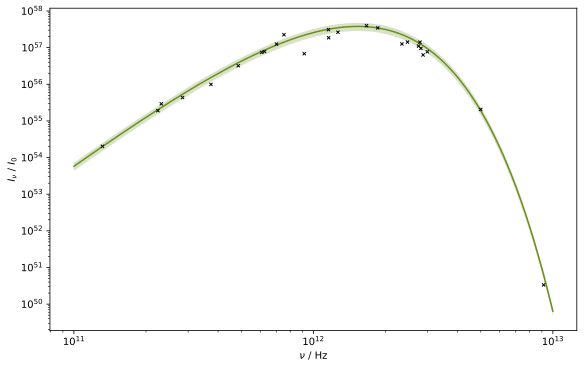

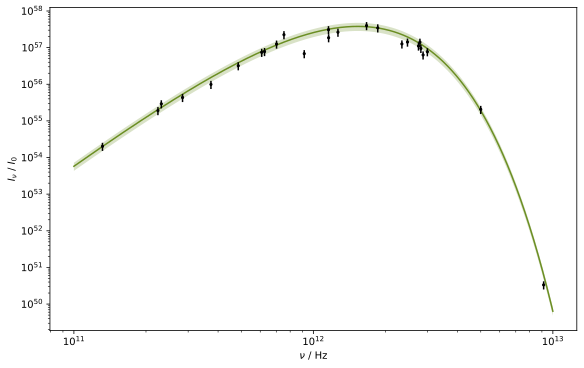

In [3]:
## Parameters
tT, tb = np.asarray([15.0]), np.asarray([1.9])

# Truth
x = np.linspace(1e11, 1e13, 1000)
y = I(x, tT, tb)

# Data
N = 25
u = 0.25 #   relative uncertaintiy

np.random.seed(123)   # set seed for pseudo random number generation

df = np.power(10, np.random.uniform(11, 13, N))

dI = I(df, tT, tb)
dI += np.random.normal(0.0, u * dI)

dIerr = u * dI

plt.fill_between(x, 1.25 * y, 0.75 * y, alpha=0.25)
plt.plot(x, y)
plt.plot(df, dI, 'kx', ms=3.21)

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$I_\nu$ / $I_0$')

plt.xscale('log')
plt.yscale('log')

plt.show()
plt.close()

# Measurement
plt.fill_between(x, 1.25 * y, 0.75 * y, alpha=0.25)
plt.plot(x, y)
plt.errorbar(df, dI, yerr=dIerr, fmt='k.', ms=4.32)

plt.xlabel(r'$\nu$ / Hz')
plt.ylabel(r'$I_\nu$ / $I_0$')

plt.xscale('log')
plt.yscale('log')

plt.show()
plt.close()

### Likelihood

Since we are assuming independent measurements, we can define

$$P(\tilde{I}_\nu|\nu,\sigma,T,\beta) = \prod_{i=1}^N p\bigl(\tilde{I}_\nu^i\big|\nu_i,\sigma_i,T,\beta\bigr) = \prod_{i=1}^N \frac{1}{\sqrt{2\pi\sigma_i^2}}\exp\left(-\frac{\bigl(\tilde{I}_\nu^i - \symup{MBB}(\nu_i,T,\beta)\bigr)^2}{2\sigma_i^2}\right)$$

as the linear likelihood or equivalently

$$\log P(\tilde{I}_\nu|\nu,\sigma,T,\beta) = -\frac{N\log 2\pi}{2} - \sum_{i=1}^N \log \sigma_i - \sum_{i=1}^N \frac{\bigl(\tilde{I}_\nu^i - \symup{MBB}(\nu_i,T,\beta)\bigr)^2}{2\sigma_i^2}$$

for the positive logarithmic likelihood.

In [4]:
def _negLogLike(mI, mf, ms, pT, pb):
    N = ms.size
    return N * np.log(2 * np.pi) / 2 + np.sum(np.log(ms)) + np.sum((mI - I(mf, pT, pb))**2 / (2 * ms**2))

def negLogLike(mI, mf, ms, pT, pb):
    N = ms.size
    Nx = pT.size
    Ny = pb.size
    return np.vectorize(_negLogLike, signature=f'({N}),({N}),({N}),({Nx}),({Ny})->({Nx},{Ny})')(mI, mf, ms, pT, pb)

#def simpNegLogLike(mI, mf, ms, pT, pb):
#    return np.sum((mI - I(mf, pT, pb))**2 / (2 * ms**2))

#def lamTest(mI, mf, ms, pT, pb):
#    return np.sum(map(lambda mI, mf, ms: (mI - I(mf, pT, pb))**2 / (2 * ms**2)), )

X = np.linspace(15, 30, 10)
Y = np.linspace(1, 2, 10)

X, Y = np.meshgrid(X, Y)

Z = negLogLike(dI, df, dIerr, X, Y) #np.array(list(map(negLogLike, dI, df, dIerr, X.flatten(), Y.flatten()))).reshape(X.shape)
plt.contourf(X, Y, Z)



ValueError: operands could not be broadcast together with shapes (25,) (10,) 